# 📌 Loading Data & Cleaning

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Load the CSV file into a DataFrame
df=pd.read_csv(r"C:\Users\mosta\Downloads\tm271_cold_chain_spoilage_risk_dataset.csv")

In [4]:
 #Display the DataFrame to verify it loaded correctly
df

,Shipment_ID,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
0,SHP-0243,5.11,4.02,69.42,13.86,275.25,8.5,50.35,3,1.0,32.94,68.97,55.80,17.97
1,SHP-0061,3.34,1.59,75.42,8.10,228.63,4.5,83.17,4,0.0,28.52,76.18,34.53,5.53
2,SHP-0217,2.81,4.13,83.89,6.71,363.17,4.7,65.48,7,1.0,33.12,67.96,75.74,12.95
3,SHP-0160,5.38,3.24,85.64,12.06,406.61,8.8,54.30,3,1.0,35.61,99.86,96.39,7.88
4,SHP-0052,3.51,3.38,72.74,6.78,306.74,10.0,59.78,4,4.0,23.94,78.11,69.06,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,SHP-0212,6.24,5.25,75.83,2.92,92.47,NaN,76.61,1,1.0,23.91,89.36,33.18,0.00
488,SHP-0068,6.01,5.69,85.42,8.52,463.29,4.1,48.90,5,3.0,32.17,76.78,89.39,25.90
489,SHP-0026,4.40,1.90,NaN,13.68,514.34,7.0,63.36,3,1.0,31.85,73.10,124.81,14.73
490,SHP-0197,2.61,1.72,73.18,NaN,20.00,6.7,68.23,3,3.0,35.06,55.84,22.53,0.00


In [5]:
# Summary statistics → understand distribution & spot outliers
df.describe()

,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
count,492.000000,492.000000,473.000000,473.000000,492.000000,473.000000,492.000000,492.000000,473.000000,492.000000,472.000000,473.000000,492.000000
mean,4.287114,4.173191,78.580063,10.101226,419.922093,6.462368,72.390041,4.916667,1.947146,34.267622,78.281864,91.882600,16.120569
std,1.837835,2.894554,7.954964,3.847761,185.485461,1.771472,13.769267,1.895210,1.363631,5.559951,10.230349,39.355652,13.474123
min,0.200000,0.170000,55.000000,1.500000,20.000000,1.400000,35.000000,0.000000,0.000000,20.000000,40.000000,8.000000,0.000000
25%,3.017500,2.060000,73.150000,7.530000,288.330000,5.200000,63.685000,4.000000,1.000000,30.385000,71.690000,64.650000,6.700000
50%,4.280000,3.490000,78.460000,10.000000,409.245000,6.500000,72.705000,5.000000,2.000000,34.025000,78.285000,90.100000,15.020000
75%,5.370000,5.420000,84.030000,12.670000,533.630000,7.600000,81.302500,6.000000,3.000000,38.055000,85.450000,116.520000,22.597500
max,12.300000,16.300000,98.000000,22.550000,900.000000,10.000000,100.000000,11.000000,7.000000,49.000000,100.000000,208.290000,99.100000


In [6]:
# Check shape → know how many rows & columns we have
df.shape


(492, 14)

In [7]:
# Check data types → ensure each column has the correct type and identify any potential issues with data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Shipment_ID               492 non-null    object 
 1   Avg_Storage_Temp_C        492 non-null    float64
 2   Temp_Excursion_Hours      492 non-null    float64
 3   Relative_Humidity_Pct     473 non-null    float64
 4   Transit_Duration_Hours    473 non-null    float64
 5   Distance_KM               492 non-null    float64
 6   Packaging_Quality_Score   473 non-null    float64
 7   Vehicle_Load_Pct          492 non-null    float64
 8   Door_Open_Events          492 non-null    int64  
 9   Ice_Replacement_Count     473 non-null    float64
 10  Ambient_Temp_C            492 non-null    float64
 11  Inspection_Hygiene_Score  472 non-null    float64
 12  Fuel_Use_Liters           473 non-null    float64
 13  Spoilage_Risk_Score       492 non-null    float64
dtypes: float64

In [8]:
# Check missing values → identify columns that need cleaning
df.isnull().sum()

Shipment_ID                  0
Avg_Storage_Temp_C           0
Temp_Excursion_Hours         0
Relative_Humidity_Pct       19
Transit_Duration_Hours      19
Distance_KM                  0
Packaging_Quality_Score     19
Vehicle_Load_Pct             0
Door_Open_Events             0
Ice_Replacement_Count       19
Ambient_Temp_C               0
Inspection_Hygiene_Score    20
Fuel_Use_Liters             19
Spoilage_Risk_Score          0
dtype: int64

In [9]:
# Check duplicates → avoid skewed analysis from repeated rows
df.duplicated().sum()

np.int64(12)

In [10]:
# Check data types → ensure each column has the correct type
df.dtypes

Shipment_ID                  object
Avg_Storage_Temp_C          float64
Temp_Excursion_Hours        float64
Relative_Humidity_Pct       float64
Transit_Duration_Hours      float64
Distance_KM                 float64
Packaging_Quality_Score     float64
Vehicle_Load_Pct            float64
Door_Open_Events              int64
Ice_Replacement_Count       float64
Ambient_Temp_C              float64
Inspection_Hygiene_Score    float64
Fuel_Use_Liters             float64
Spoilage_Risk_Score         float64
dtype: object

# Exploratory Analysis and Visualization

In [11]:
df.corr(numeric_only=True)

,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
Avg_Storage_Temp_C,1.000000,0.075468,-0.004670,0.061017,0.046865,-0.048940,-0.004816,-0.090778,-0.063198,-0.024255,0.038856,0.037631,0.536313
Temp_Excursion_Hours,0.075468,1.000000,0.019706,-0.041987,-0.031893,0.015503,0.067465,0.000483,-0.034018,0.033986,-0.009098,-0.034851,0.416057
Relative_Humidity_Pct,-0.004670,0.019706,1.000000,0.061384,0.053218,0.017127,-0.011362,-0.019885,0.059122,0.049494,-0.095168,0.069708,0.064411
Transit_Duration_Hours,0.061017,-0.041987,0.061384,1.000000,0.819320,-0.046310,-0.006683,-0.040908,0.045023,0.021986,0.021867,0.853360,0.467897
Distance_KM,0.046865,-0.031893,0.053218,0.819320,1.000000,-0.019586,0.019706,-0.046301,0.014330,0.013801,0.007527,0.976438,0.503223
Packaging_Quality_Score,-0.048940,0.015503,0.017127,-0.046310,-0.019586,1.000000,-0.055977,0.012022,-0.005808,0.021180,0.144827,0.016745,-0.309490
Vehicle_Load_Pct,-0.004816,0.067465,-0.011362,-0.006683,0.019706,-0.055977,1.000000,0.013150,0.037948,-0.024119,-0.000194,0.030952,0.115484
Door_Open_Events,-0.090778,0.000483,-0.019885,-0.040908,-0.046301,0.012022,0.013150,1.000000,-0.046603,-0.051260,0.042203,-0.052682,-0.032283
Ice_Replacement_Count,-0.063198,-0.034018,0.059122,0.045023,0.014330,-0.005808,0.037948,-0.046603,1.000000,-0.039848,0.000355,0.028444,-0.113676
Ambient_Temp_C,-0.024255,0.033986,0.049494,0.021986,0.013801,0.021180,-0.024119,-0.051260,-0.039848,1.000000,-0.057396,0.009472,0.114403


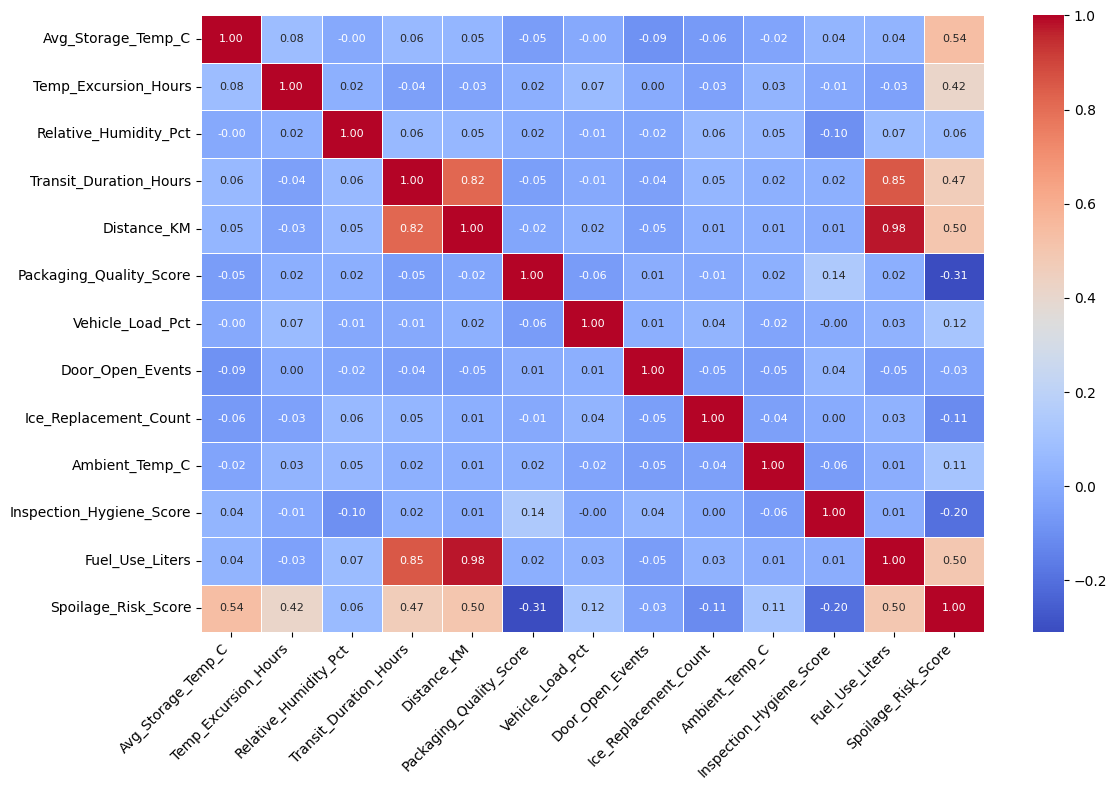

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # تكبير حجم الرسمة

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",              # تقليل الأرقام لرقمين عشريين
    cmap="coolwarm",        # ألوان أوضح
    linewidths=0.5,         # خطوط بين الخلايا
    annot_kws={"size": 8}   # تصغير حجم الخط
)

plt.xticks(rotation=45, ha='right')  # لف أسماء الأعمدة
plt.yticks(rotation=0)

plt.tight_layout()  
plt.show()

<Axes: xlabel='Avg_Storage_Temp_C', ylabel='Spoilage_Risk_Score'>

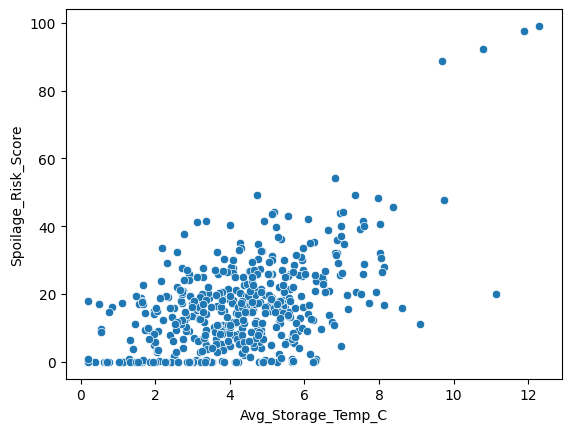

In [13]:
sns.scatterplot(x="Avg_Storage_Temp_C", y="Spoilage_Risk_Score", data=df)

<Axes: >

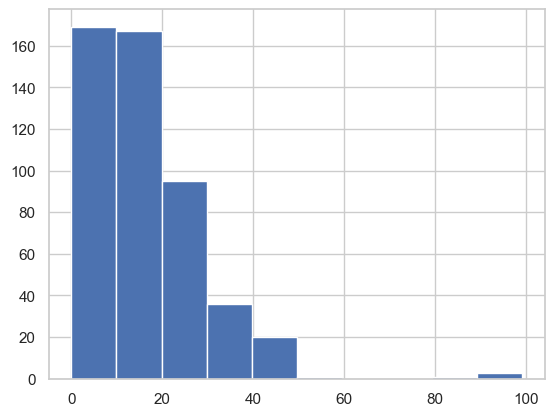

In [37]:
df["Spoilage_Risk_Score"].hist()

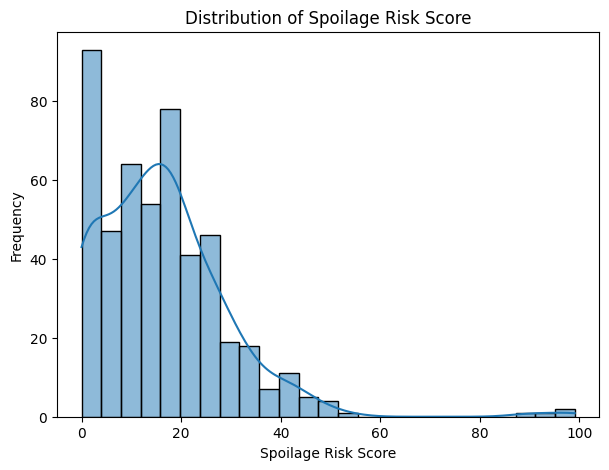

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(df["Spoilage_Risk_Score"], kde=True)
plt.title("Distribution of Spoilage Risk Score")
plt.xlabel("Spoilage Risk Score")
plt.ylabel("Frequency")
plt.show()

C:\Users\mosta\AppData\Local\Temp\ipykernel_15696\4255423152.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


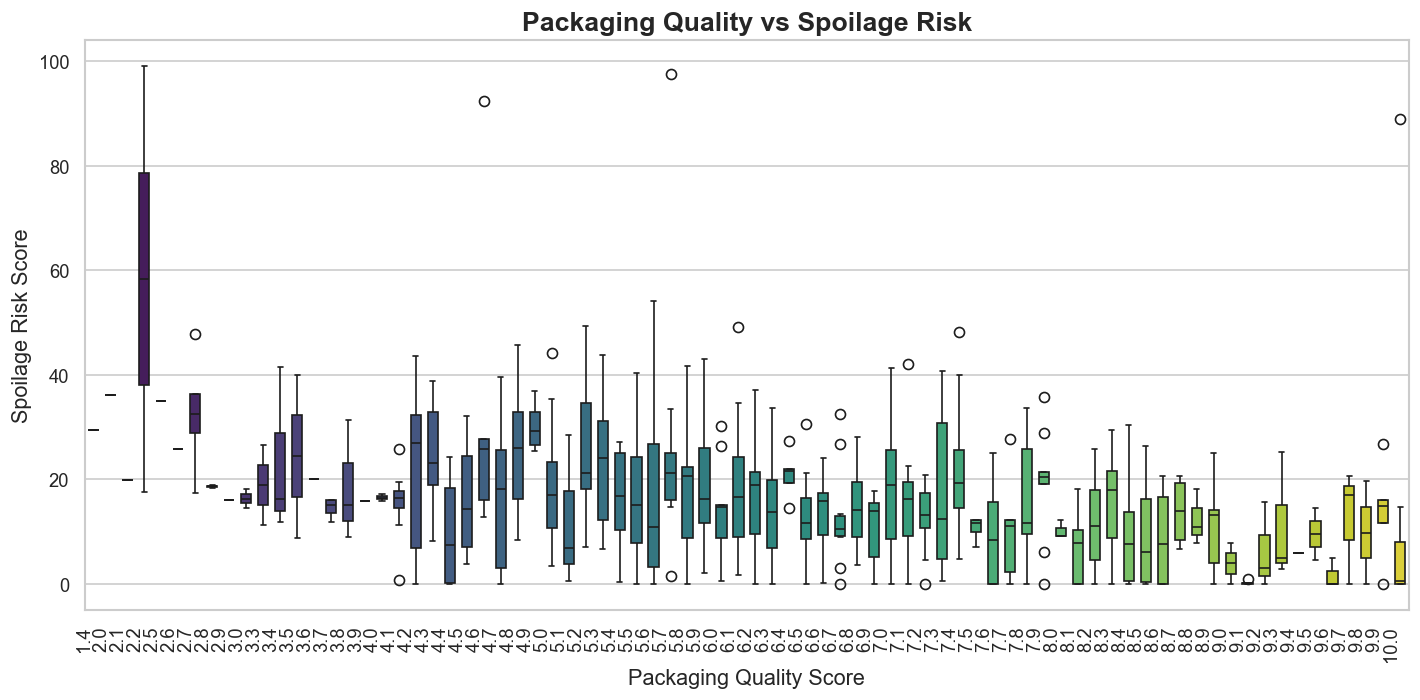

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6), dpi=120)  

ax = sns.boxplot(
    x="Packaging_Quality_Score",
    y="Spoilage_Risk_Score",
    data=df,
    palette="viridis",
    width=0.6
)

plt.title("Packaging Quality vs Spoilage Risk", fontsize=16, weight='bold')
plt.xlabel("Packaging Quality Score", fontsize=13)
plt.ylabel("Spoilage Risk Score", fontsize=13)

# حل مشكلة تزاحم الأرقام
plt.xticks(rotation=90, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()  
plt.show()

# Handling Data

In [ ]:
df['Packaging_Quality_Score'].fillna(df['Packaging_Quality_Score'].median(), inplace=True)
df['Relative_Humidity_Pct'].fillna(df['Relative_Humidity_Pct'].mean(), inplace=True)


from sklearn.impute import KNNImputer

# اختيار الأعمدة اللي فيها missing values
cols = ['Transit_Duration_Hours']

# إنشاء الـ KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# تطبيق الـ imputer على الأعمدة
df[cols] = imputer.fit_transform(df[cols])

C:\Users\mosta\AppData\Local\Temp\ipykernel_15696\4243063192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Packaging_Quality_Score'].fillna(df['Packaging_Quality_Score'].median(), inplace=True)
C:\Users\mosta\AppData\Local\Temp\ipykernel_15696\4243063192.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [40]:
df.isnull().sum()

Shipment_ID                 0
Avg_Storage_Temp_C          0
Temp_Excursion_Hours        0
Relative_Humidity_Pct       0
Transit_Duration_Hours      0
Distance_KM                 0
Packaging_Quality_Score     0
Vehicle_Load_Pct            0
Door_Open_Events            0
Ice_Replacement_Count       0
Ambient_Temp_C              0
Inspection_Hygiene_Score    0
Fuel_Use_Liters             0
Spoilage_Risk_Score         0
Temp_Abuse_Index            0
Cooling_Protection_Ratio    0
Load_Stress_Index           0
dtype: int64

# Feature Transformation 

In [18]:
# Derived Feature 1: Temperature Abuse Index
df["Temp_Abuse_Index"] = df["Avg_Storage_Temp_C"] * df["Temp_Excursion_Hours"]

In [19]:
# Derived Feature 2: Cooling Protection Ratio
df["Cooling_Protection_Ratio"] = (
    df["Packaging_Quality_Score"] + df["Ice_Replacement_Count"]
) / df["Transit_Duration_Hours"]

In [20]:
# Derived Feature 3: Load Stress Index
df["Load_Stress_Index"] = (
    df["Vehicle_Load_Pct"] * df["Transit_Duration_Hours"]
) / 100

In [21]:
df[["Temp_Abuse_Index", "Cooling_Protection_Ratio", "Load_Stress_Index"]].head()

,Temp_Abuse_Index,Cooling_Protection_Ratio,Load_Stress_Index
0,20.5422,0.685426,6.978510
1,5.3106,0.555556,6.736770
2,11.6053,0.849478,4.393708
3,17.4312,0.812604,6.548580
4,11.8638,2.064897,4.053084


In [22]:
df

,Shipment_ID,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score,Temp_Abuse_Index,Cooling_Protection_Ratio,Load_Stress_Index
0,SHP-0243,5.11,4.02,69.420000,13.860000,275.25,8.5,50.35,3,1.0,32.94,68.97,55.80,17.97,20.5422,0.685426,6.978510
1,SHP-0061,3.34,1.59,75.420000,8.100000,228.63,4.5,83.17,4,0.0,28.52,76.18,34.53,5.53,5.3106,0.555556,6.736770
2,SHP-0217,2.81,4.13,83.890000,6.710000,363.17,4.7,65.48,7,1.0,33.12,67.96,75.74,12.95,11.6053,0.849478,4.393708
3,SHP-0160,5.38,3.24,85.640000,12.060000,406.61,8.8,54.30,3,1.0,35.61,99.86,96.39,7.88,17.4312,0.812604,6.548580
4,SHP-0052,3.51,3.38,72.740000,6.780000,306.74,10.0,59.78,4,4.0,23.94,78.11,69.06,0.00,11.8638,2.064897,4.053084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,SHP-0212,6.24,5.25,75.830000,2.920000,92.47,6.5,76.61,1,1.0,23.91,89.36,33.18,0.00,32.7600,2.568493,2.237012
488,SHP-0068,6.01,5.69,85.420000,8.520000,463.29,4.1,48.90,5,3.0,32.17,76.78,89.39,25.90,34.1969,0.833333,4.166280
489,SHP-0026,4.40,1.90,78.580063,13.680000,514.34,7.0,63.36,3,1.0,31.85,73.10,124.81,14.73,8.3600,0.584795,8.667648
490,SHP-0197,2.61,1.72,73.180000,10.101226,20.00,6.7,68.23,3,3.0,35.06,55.84,22.53,0.00,4.4892,0.960279,6.892067


# *Feature Scaling and Dimensionality Reduction*

In [23]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

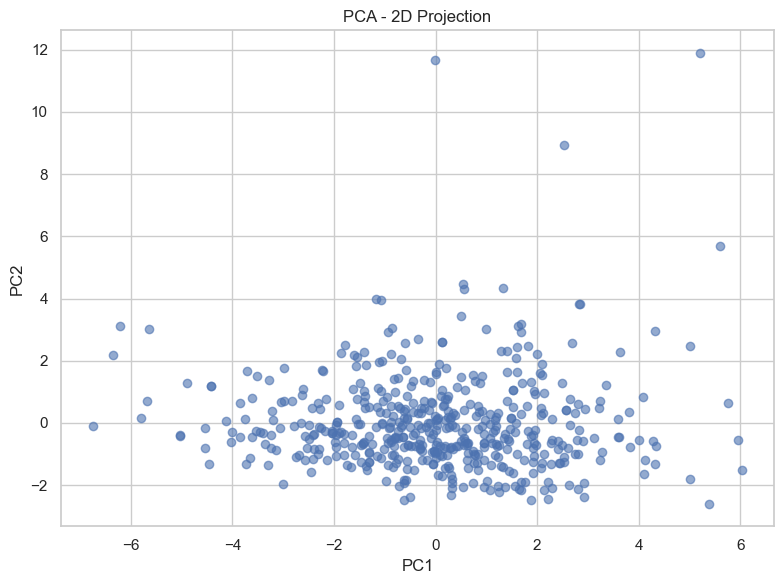

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Imputation (ملء القيم الفاضية)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df[numeric_features]),
                          columns=numeric_features)

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.6)
plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# *Baseline Models* 	

In [ ]:
from sklearn.impute import SimpleImputer

# نختار الأعمدة الرقمية فقط
numeric_cols = df.select_dtypes(include=np.number).columns

# إنشاء imputer
imputer = SimpleImputer(strategy="mean")

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [27]:
# Features (X) and Target (y)
X = df.drop(columns=["Shipment_ID", "Spoilage_Risk_Score"])
y = df["Spoilage_Risk_Score"]

In [28]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Features & Target
X = df.drop(columns=["Shipment_ID", "Spoilage_Risk_Score"])
y = df["Spoilage_Risk_Score"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 1. Linear Regression
# ===============================
lr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

# ===============================
# 2. Decision Tree Regressor
# ===============================
dt_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

# ===============================
# 3. Support Vector Regressor (SVR)
# ===============================
svr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", SVR())
])

svr_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,kernel,'rbf'


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_svr = svr_model.predict(X_test)

# Evaluation function
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

# Results
lr_results = evaluate(y_test, y_pred_lr)
dt_results = evaluate(y_test, y_pred_dt)
svr_results = evaluate(y_test, y_pred_svr)



In [34]:

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "SVR"],
    "MAE": [lr_results[0], dt_results[0], svr_results[0]],
    "RMSE": [lr_results[1], dt_results[1], svr_results[1]],
    "R2 Score": [lr_results[2], dt_results[2], svr_results[2]]
})

print(results_df)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  3.490613   4.962441  0.844738
1      Decision Tree  7.024242   9.987606  0.371076
2                SVR  8.106028  11.287627  0.196695


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Random Forest Model
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest -> MAE:", mae_rf, "RMSE:", rmse_rf, "R2:", r2_rf)

Random Forest -> MAE: 4.448429292929293 RMSE: 6.713623770093439 R2: 0.7158228416113372
